### setup

In [ ]:
import os
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import TQDMProgressBar

from mlcolvar.cvs import DeepLDA
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_files, load_dataframe
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.fes import compute_fes
from mlcolvar.explain import sensitivity_analysis
import mlcolvar.utils.plot
import plumed


In [4]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data2"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
#NUM_STEPS   = 10_000     # for testing  
NUM_STEPS   = 500_000    # productions 1ns
STRIDE      = 100

num_steps   = NUM_STEPS
sample_steps = 1_000_000
sample_stride = 100

os.chdir(BASE_DIR)
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [5]:
# helper functions

# delete outputs of simulations from `folder``
def clean(folder='./'):
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# delete outputs of simulations from `folder``
def clean_true(folder='./'):
    subprocess.run("rm -f bck.* COLVAR HILLS KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# execute bash command in the given folder
def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output = True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

## 1.0 Unbiased simulations in the metastable states

First, we perform short MD simulations starting from the two snapshots of the molecule, and characterizing each state with a set of descriptors. To proceed in a blind way, we choose to use as input features all the distances between heavy atoms (the list of such descriptors are in the file `plumed-distances.dat`).

**State A**

In [7]:
# CREATE FOLDER AND COPY INPUTS
folderA = DATA_DIR / "0_unbiased-sA/"
Path(folderA).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folderA)
execute(f"cp {MD_IN_DIR}/input.tpr .", folderA)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [9]:
# WRITE PLUMED INPUT FILE
with open(folderA / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Print 
PRINT FMT=%g STRIDE={sample_stride} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [ ]:
#clean(folderA) # note: this deletes all previous results in folder!

In [10]:
# print command to run in terminal (for longer run)

print(f"cd {folderA}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {sample_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data2/0_unbiased-sA
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 1000000 -v


**State B**

In [11]:
# CREATE FOLDER AND COPY INPUTS
folderB = DATA_DIR / "0_unbiased-sB/"
Path(folderB).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folderB)
execute(f"cp {MD_IN_DIR}/input.sB.tpr input.tpr", folderB)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.sB.tpr input.tpr


In [12]:
# WRITE PLUMED INPUT FILE
with open(folderB / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Print 
PRINT FMT=%g STRIDE={sample_stride} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [ ]:
#clean(folderB) # note: this deletes all previous results in folder!

In [13]:
# print command to run in terminal (for longer run)

print(f"cd {folderB}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {sample_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data2/0_unbiased-sB
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 1000000 -v


### Analize data generated

Ramachandran plot of the two simulations

σ(φ) State A: 0.5587 rad
σ(φ) State B: 0.1336 rad


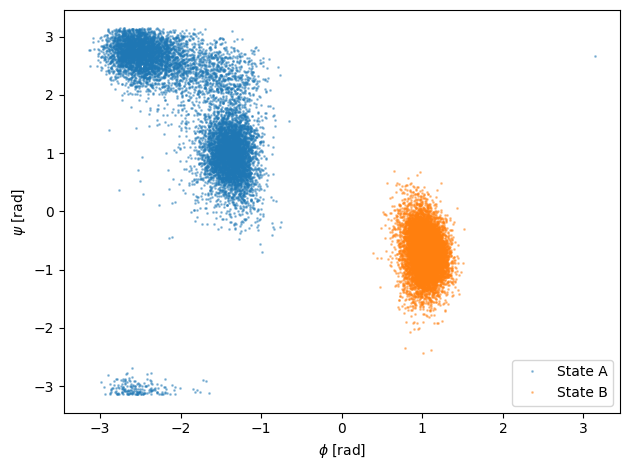

In [20]:
# import PLUMED COLVAR files into pandas datasets
dataA = load_dataframe(f"{folderA}/COLVAR")
dataB = load_dataframe(f"{folderB}/COLVAR")
# plot phi vs psi
fig, ax = plt.subplots()
ax.plot(dataA["phi"], dataA["psi"], 'o', alpha=0.4, ms=1, label="State A")
ax.plot(dataB["phi"], dataB["psi"], 'o', alpha=0.4, ms=1, label="State B")
ax.set_xlabel(r"$\phi$ [rad]")
ax.set_ylabel(r"$\psi$ [rad]")
ax.legend()
plt.tight_layout()

# calculate gaussian sigma
for label, data in [("A", dataA), ("B", dataB)]:
    print(f"σ(φ) State {label}: {np.std(data['phi']):.4f} rad")

## 1.1 DeepLDA CV on pairwise distances (heavy atoms) 

### (a) Train CV

To load the PLUMED output of the two unbiased MD runs we can use the [load_dataframe](https://mlcvs.readthedocs.io/en/latest/autosummary/mlcvs.utils.io.load_dataframe.html) function.
From this data, we build our training dataset. Since this is a supervised learning task, the dataset will be of the form (`X,y`), in which `X` are the input samples and `y` the corresponding labels (the states to which they belong to).

In [22]:
torch.set_float32_matmul_precision('high')

# Detect available accelerator
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
#accelerator = 'cpu'
print(f"Training on: {accelerator.upper()}")

Training on: GPU


### Load data

In [ ]:
filenames = [ f"{DATA_DIR}/0_unbiased-sA/COLVAR", 
              f"{DATA_DIR}/0_unbiased-sB/COLVAR" ]

n_states = len(filenames)

# load dataset
dataset, colvar = create_dataset_from_files(filenames,
                                        filter_args={'regex':'d_' }, # select distances between heavy atoms
                                        create_labels=True,
                                        return_dataframe=True, 
                                        )

# default parameters batch size = len(dataset), shuffle = True
datamodule = DictModule(dataset,lengths=[0.8,0.2])

Class 0 dataframe shape:  (10001, 53)
Class 1 dataframe shape:  (10001, 53)

 - Loaded dataframe (20002, 53): ['time', 'phi', 'psi', 'theta', 'xi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (20002, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_

We can inspect the distances through their histograms, from which we notice that no one is able to discriminate between the states.

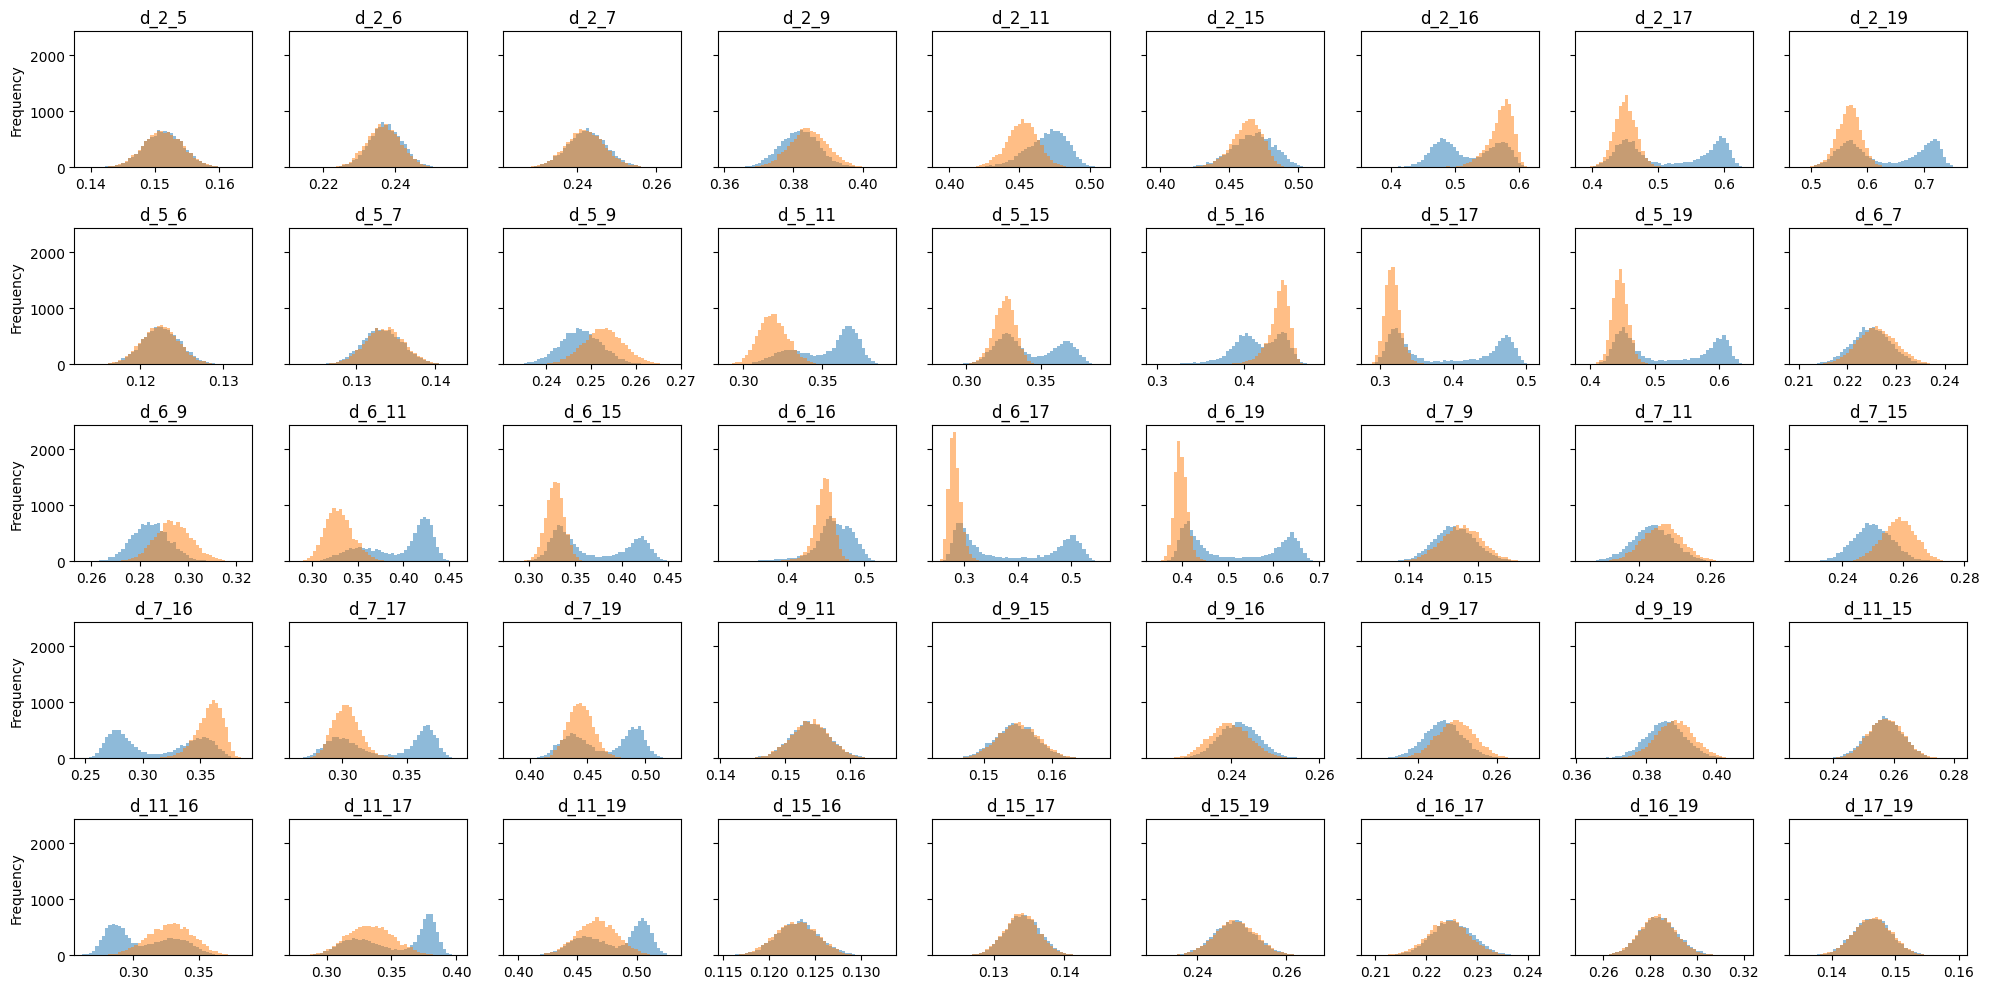

In [24]:
descriptors_names = colvar.filter(regex='d_').columns.values

fig,axs = plt.subplots(5,9,figsize=(20,10),sharey=True)

for ax,desc in zip(axs.flatten(),descriptors_names):
    colvar.pivot(columns='labels')[desc].plot.hist(bins=50,alpha=0.5,ax=ax,legend=False)
    ax.set_title(desc)

plt.tight_layout()

### Train DeepLDA 

Define model

In [25]:
#------------- PARAMETERS -------------
n_input           = dataset['data'].shape[-1]
nodes             = [n_input,30,30,5]
activation        = 'tanh'  # changed from relu

lrate             = 0.001
sw_reg            = 0.05
l2_reg            = 1e-5

num_epochs        = 500
es_patience       = 50
es_min_delta      = 0.1

log_every         = 100
#--------------------------------------

nn_args = {'activation': activation}
options= {'nn': nn_args}

# MODEL
model = DeepLDA(nodes, n_states=n_states, options=options)

# OPTIMIZER: here we use adam
model.optimizer_name = "Adam"
model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}

# REGULARIZATION: add regularization to the calculation of the S_w matrix
model.sw_reg = sw_reg

model

DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=30, bias=True)
      (1): Tanh()
      (2): Linear(in_features=30, out_features=30, bias=True)
      (3): Tanh()
      (4): Linear(in_features=30, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)

Define trainer and fit

In [26]:
# define callbacks
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", 
    min_delta=es_min_delta, 
    patience=es_patience,
    mode="min")

tqdm_progress_bar = TQDMProgressBar(refresh_rate=50)

# define trainer
trainer = lightning.Trainer(callbacks=[metrics, early_stopping, tqdm_progress_bar],
                     max_epochs=num_epochs, logger=None, enable_checkpointing=False,
                     accelerator=accelerator, enable_progress_bar=True, enable_model_summary=True)

# fit
trainer.fit( model, datamodule )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-07-07 10:21:17.073508: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 10:21:17.797473: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-07 10:21:20.201920: I tensorflow/core/util/port.cc:153] oneDNN cust

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.5 K │ train │ 4.8 K │  [1, 45] │    [1, 5] │
│ 3 │ lda     │ LDA                   │      0 │ train │    10 │   [1, 5] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.8 K

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

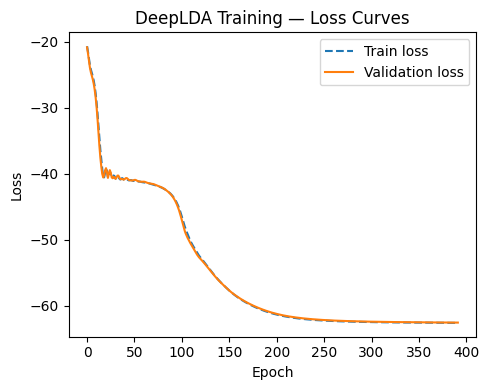

In [27]:
ax = plot_metrics(metrics.metrics, 
                  keys=['train_loss_epoch','valid_loss'],
                  linestyles=['--','-'],
                  yscale='linear')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("DeepLDA Training — Loss Curves")
ax.legend(["Train loss", "Validation loss"])

plt.tight_layout()

To better understand what the network is doing, we can inspect the output of the NN, before the application of LDA. 

--> **Question**: What are the differences with the input descriptors?

In [28]:
X_dist = colvar.filter(like='d_', axis=1)

X = torch.tensor(X_dist.values, dtype=torch.float32)
y = torch.tensor(colvar['labels'].values, dtype=torch.long)

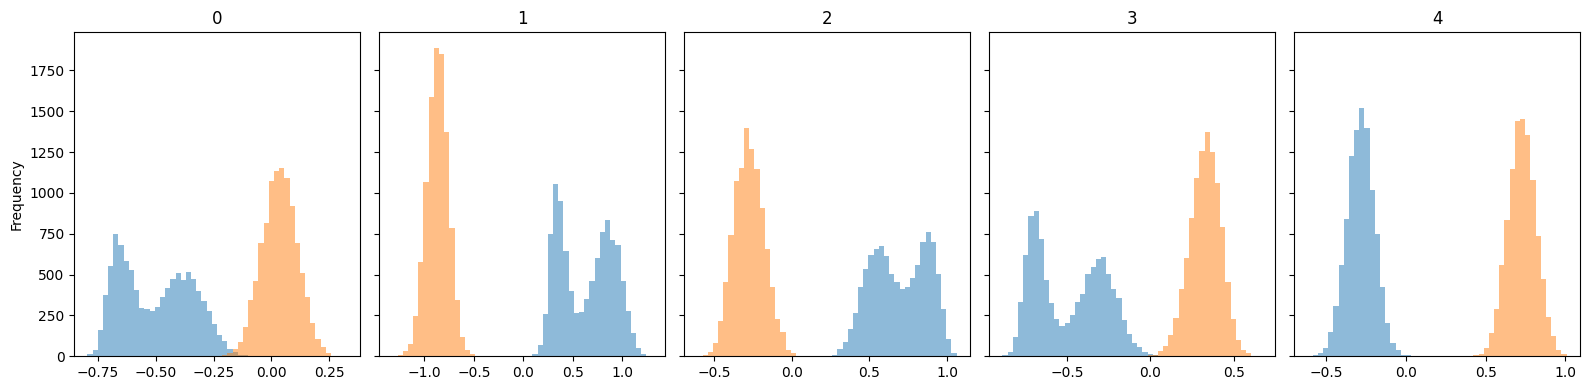

In [29]:
model.eval()
with torch.no_grad():
    hidden = model.forward_nn(X).numpy()
df_h = pd.DataFrame( hidden )
df_h ['label'] = y

# Plot histogram in the two state
fig,axs = plt.subplots(1,nodes[-1],figsize=(16,4),sharey=True)

hidden_names = [i for i in range(nodes[-1])]

for ax,desc in zip(axs.flatten(),hidden_names):
    df_h.pivot(columns='label')[desc].plot.hist(bins=50,alpha=0.5,ax=ax,legend=False)
    ax.set_title(desc)

plt.tight_layout()

Finally, we can look at the histogram of the CV (right), which shows that the two states are mapped around -1 and +1. To appreciate the discriminative power, we can also inspect the Ramachandran plot (left) of the two torsion angles phi and psi where we colored the points according to the value of the Deep-LDA CV.

In [30]:
# Define a few plotting functions

def plot_ramachandran(x,y,z,scatter=None, ax=None):
    # Setup plot
    if ax is None:
        _, ax = plt.subplots(figsize=(5,4.), dpi=100)
        ax.set_title(f'Ramachandran plot')

    # Plot countour plot
    h = ax.hexbin(x,y,C=z,cmap='fessa')
    cbar = plt.colorbar(h,ax=ax)
    cbar.set_label(f'Deep-LDA CV')

    ax.set_xlabel(r'$\phi$ [rad]')
    ax.set_ylabel(r'$\psi$ [rad]')

def plot_cv_histogram(s,label=None,ax=None,**kwargs):
    # Setup plot
    if ax is None:
        _, ax = plt.subplots(figsize=(5,4.), dpi=100)
        ax.set_title('Histogram')

    if (type(s)==torch.Tensor):
        s = s.squeeze(1).detach().numpy()

    # Plot histogram
    ax.hist(s,**kwargs)
    if label is not None:
        ax.set_xlabel(label)

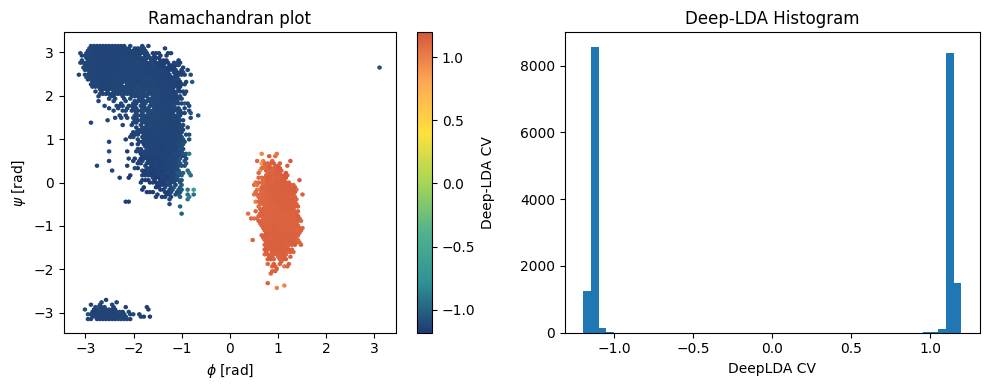

In [31]:
_, axs = plt.subplots(1,2, figsize=(10,4.), dpi=100)

axs[0].set_title('Ramachandran plot')
with torch.no_grad():
    s = model(X)
    
plot_ramachandran(colvar['phi'],colvar['psi'],s,ax=axs[0])

# Calculate CV values over training set
axs[1].set_title(f'Deep-LDA Histogram')
plot_cv_histogram(s, label="DeepLDA CV", bins=50, ax=axs[1])

plt.tight_layout()

#### Number of NN outputs

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


NN outputs = 10


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.6 K │ train │ 5.1 K │  [1, 45] │   [1, 10] │
│ 3 │ lda     │ LDA                   │      0 │ train │    20 │  [1, 10] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.6 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 5.1 K

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Trainable params: 2.4 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.7 K

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


NN outputs = 1


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.3 K │ train │ 4.6 K │  [1, 45] │    [1, 1] │
│ 3 │ lda     │ LDA                   │      0 │ train │     2 │   [1, 1] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.3 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.3 K                                                                                                
Total estimated model params size (MB): 0.009                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.6 K

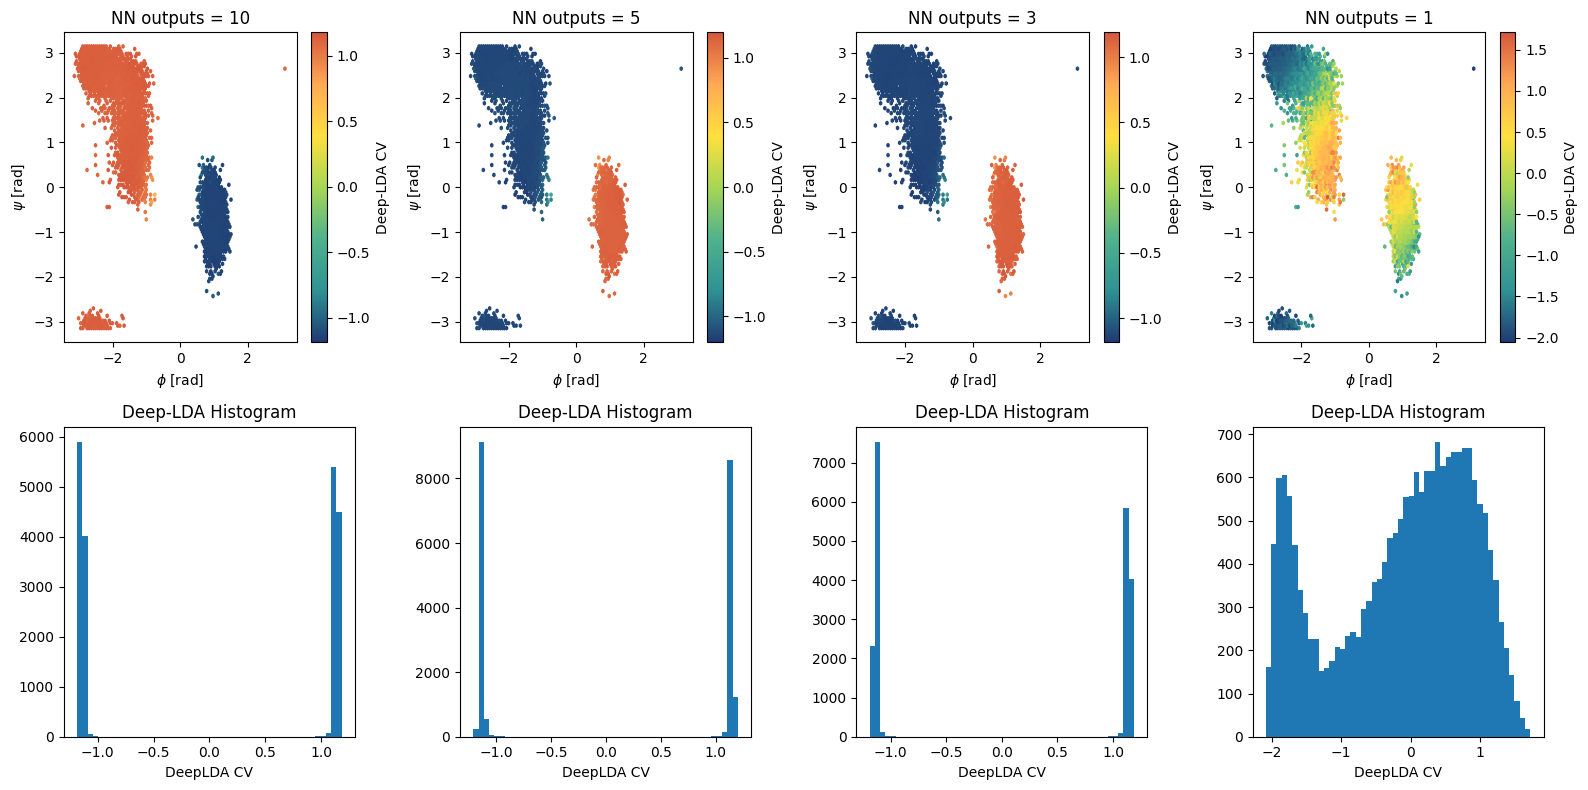

In [32]:
nn_out = [10,5,3,1]

fig, axs = plt.subplots(2,len(nn_out),figsize=(16,8),dpi=100)

for i,out in enumerate(nn_out):
    print(f'NN outputs = {out}')
    # ARCHITECTURE
    nodes = [X.size(1),30,30,out]
    test_model = DeepLDA(nodes, n_states=n_states, options=options)

    # OPTIMIZER: here we use adam
    test_model.optimizer_name = "Adam"
    test_model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}

    # REGULARIZATION: add regularization to the calculation of the S_w matrix
    test_model.sw_reg = sw_reg

    metrics = MetricsCallback()
    early_stopping = EarlyStopping(monitor="valid_loss", 
                                min_delta=es_min_delta, 
                                patience=es_patience,
                                mode="min")
    
    #tqdm_progress_bar = TQDMProgressBar(refresh_rate=50)

    # TRAIN
    trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                     max_epochs=num_epochs, logger=None, enable_checkpointing=False,
                     accelerator=accelerator, enable_progress_bar=False, enable_model_summary=True)

    # fit
    trainer.fit( test_model, datamodule )

    # PREDICT
    with torch.no_grad():
        s = test_model(X)
    
    # PLOT
    axs[0][i].set_title(f'NN outputs = {out}')
    plot_ramachandran(colvar['phi'],colvar['psi'],s,ax=axs[0][i])
    axs[1][i].set_title(f'Deep-LDA Histogram')
    plot_cv_histogram(s,label="DeepLDA CV",bins=50, ax=axs[1][i] )

plt.tight_layout()

#### Extra: features relevance

We can compute the relevance of the input features from the derivatives of the cv $s$ with respect to the descriptors $d_i$:
$$r_i = \sum_{j=1} ^{n} |\frac{\partial s^{(j)}}{\partial d_i ^{(j)}}|\ \sigma(d_i)$$
where the sum is over the configurations in the training set and $\sigma$ is the standard deviation of the descriptor.

KEY:  data


KEY:  labels




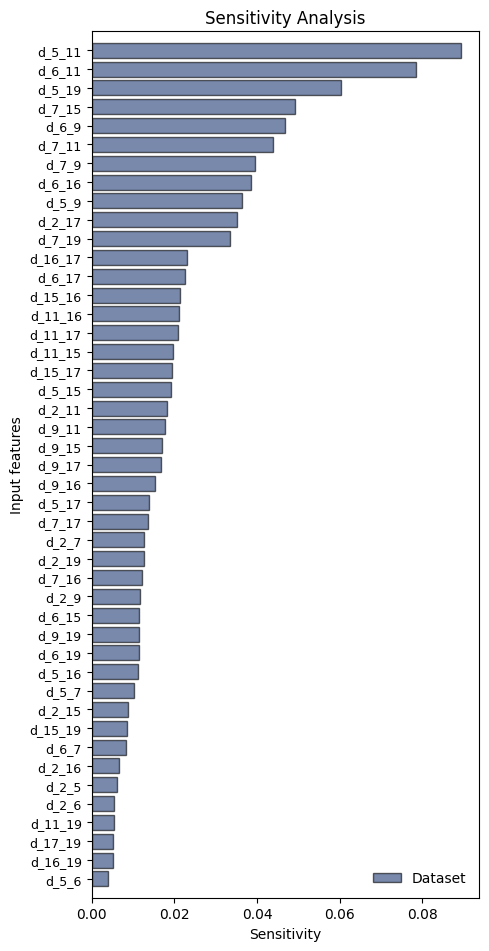

In [33]:
results = sensitivity_analysis(model, dataset, feature_names=dataset.feature_names, per_class=False, plot_mode='barh')

This allows us to identify four dominant features. Indeed, if we plot their distributions, we find that these features undergo significant changes when going from the reactant to the product states

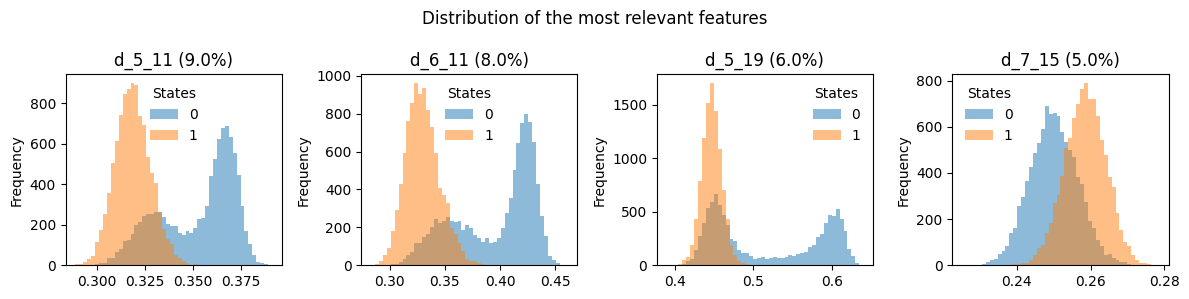

In [34]:
plot_n_features = 4

names = results['feature_names'][-plot_n_features:]
sensitivity = results['sensitivity']['Dataset'][-plot_n_features:]

fig, axs = plt.subplots(1,plot_n_features,figsize=(3*plot_n_features,3))
plt.suptitle('Distribution of the most relevant features')

for ax,name,sensitivity in zip(axs.flatten()[::-1],names,sensitivity):
    colvar.pivot(columns='labels')[name].plot.hist(bins=50,alpha=0.5,ax=ax)
    ax.set_title(f'{name} ({np.round(sensitivity*100)}%)')
    ax.legend(title='States',frameon=False)

plt.tight_layout()

### Export model for biased simulation

In [ ]:
# CREATE FOLDER AND EXPORT MODEL
folder_ml = DATA_DIR / "1_meta-deeplda/"
Path(folder_ml).mkdir(parents=True, exist_ok=True)

# export
model.eval()
model.to_torchscript(str(folder_ml / "model.ptc"), method="trace")

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/core/module.py:1549: `LightningModule.to_torchscript` has been deprecated in v2.7 and will be removed in v2.8. TorchScript is deprecated in PyTorch. Use `torch.export.export()` for model exporting instead. See https://pytorch.org/docs/stable/export.html for more information.


DeepLDA(
  original_name=DeepLDA
  (loss_fn): ReduceEigenvaluesLoss(original_name=ReduceEigenvaluesLoss)
  (norm_in): Normalization(original_name=Normalization)
  (nn): FeedForward(
    original_name=FeedForward
    (nn): Sequential(
      original_name=Sequential
      (0): Linear(original_name=Linear)
      (1): Tanh(original_name=Tanh)
      (2): Linear(original_name=Linear)
      (3): Tanh(original_name=Tanh)
      (4): Linear(original_name=Linear)
    )
  )
  (lda): LDA(original_name=LDA)
)

### (b) Bias DeepLDA

In [7]:
folder_ml = DATA_DIR / "1_meta-deeplda/"
execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_ml)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_ml)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [52]:
STRIDE_ML = 100

In [53]:
# WRITE PLUMED INPUT FILE
with open(folder_ml / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

metad: METAD ARG=deep.node-0 ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi 
...

# Print 
PRINT FMT=%g STRIDE={STRIDE_ML} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [ ]:
#clean(folder_ml) # note: this deletes all previous results in folder!

In [88]:
#num_steps=2_500_000 # 5ns
num_steps=10_000_000 # 20ns

In [89]:
# print command to run in terminal (for longer run)

print(f"cd {folder_ml}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data2/1_meta-deeplda
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000000 -v


Once the simulation is over, we can plot the time evolution of the Deep-LDA CV, in which several transitions between the states A and B (-1 and 1) can be observed. Furthermore, we can look at the Ramachandran plot to see the explored region.

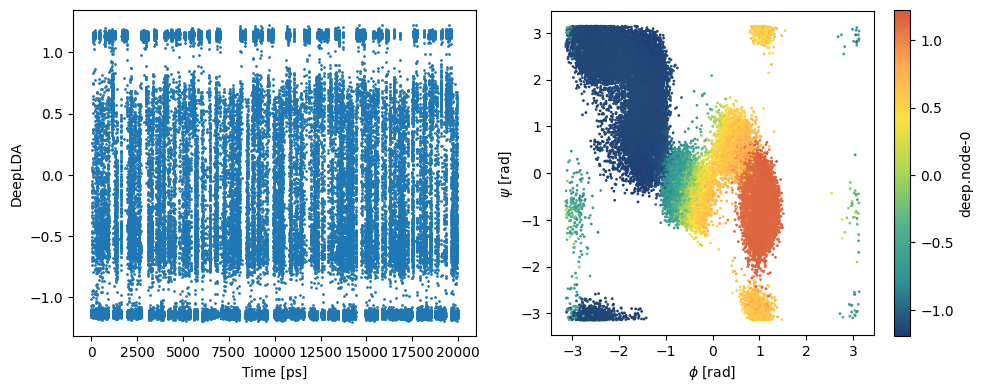

In [90]:
colvar_ml = load_dataframe(f"{folder_ml}/COLVAR")

fig,axs = plt.subplots(1,2,figsize=(10,4),dpi=100)
# Time evolution (DeepLDA)
colvar_ml.plot.scatter('time','deep.node-0',s=1,ax=axs[0])
axs[0].set_xlabel('Time [ps]')
axs[0].set_ylabel('DeepLDA')
# 2D scatter plot colored with DeepLDA
colvar_ml.plot.scatter('phi','psi',c='deep.node-0',s=1,cmap='fessa',ax=axs[1])
axs[1].set_xlabel(r'$\phi$ [rad]')
axs[1].set_ylabel(r'$\psi$ [rad]')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'DeepLDA')

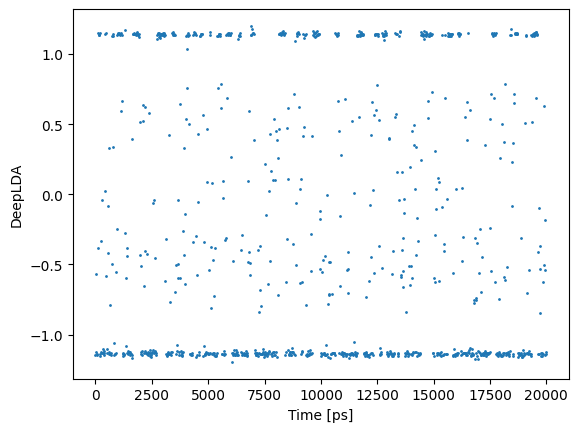

In [95]:
plt.plot(colvar_ml["time"][::100],colvar_ml["deep.node-0"][::100],'o', ms=1)
# x-y axis labels
plt.xlabel("Time [ps]")
plt.ylabel("DeepLDA")

(0.0, 50.0)

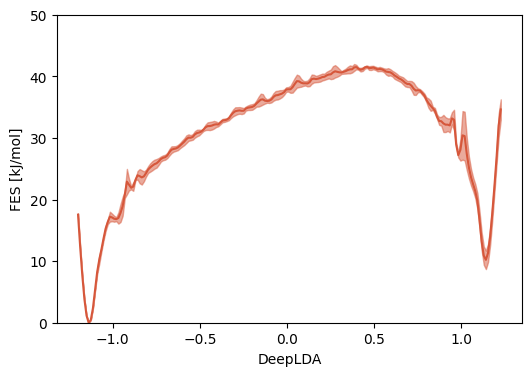

In [96]:
s = colvar_ml['deep.node-0'].values

# compute weights
kbT = 2.5
w = np.exp(colvar_ml['metad.bias'].values/kbT)

fig,ax = plt.subplots(figsize=(6,4),dpi=100)
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('DeepLDA')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)

--> **Exercise**: calculate the FES as a function of other variables, such as the Ramachandran angles `phi` and `psi`.

Note: the function `compute_fes` uses the function `KernelDensity` from scikit-learn package to perform Kernel Density Estimation (KDE). While this allows us to easily perform KDE on many dimensions, we need to take into account the periodicity of the CV. One simple solution is to perform data augmentation

In [49]:
def augment_periodic(cv,weights=None,bandwidth=0.1):
    """Add points across the periodic boundaries (-np.pi and np.pi)

    Parameters
    ----------
    cv : np.array
    weigths : np.array, optional
    bandwidth : float, optional
    """
    mask = (cv < -np.pi + 3*bandwidth)
    index = np.argwhere(mask)[:,0]
    cv = np.insert( cv, index, cv[mask] + 2*np.pi )
    if weights is not None:
        weights = np.insert( weights, index, weights[mask] )

    mask = (cv > np.pi  - 5*bandwidth) & ( cv < np.pi )
    index = np.argwhere(mask)[:,0]
    cv = np.insert( cv, np.argwhere(mask)[:,0], cv[mask] - 2*np.pi )
    if weights is not None:
        weights = np.insert( weights, index, weights[mask] )

    return cv, weights

In [97]:
phi_ml = colvar_ml['phi'].values
psi_ml = colvar_ml['psi'].values
w_ml = np.exp(colvar_ml['metad.bias'].values/kbT)

bandwidth = 0.05

phi_ml, w_phi_ml = augment_periodic(phi_ml,w_ml,bandwidth)
psi_ml, w_psi_ml = augment_periodic(psi_ml,w_ml,bandwidth)

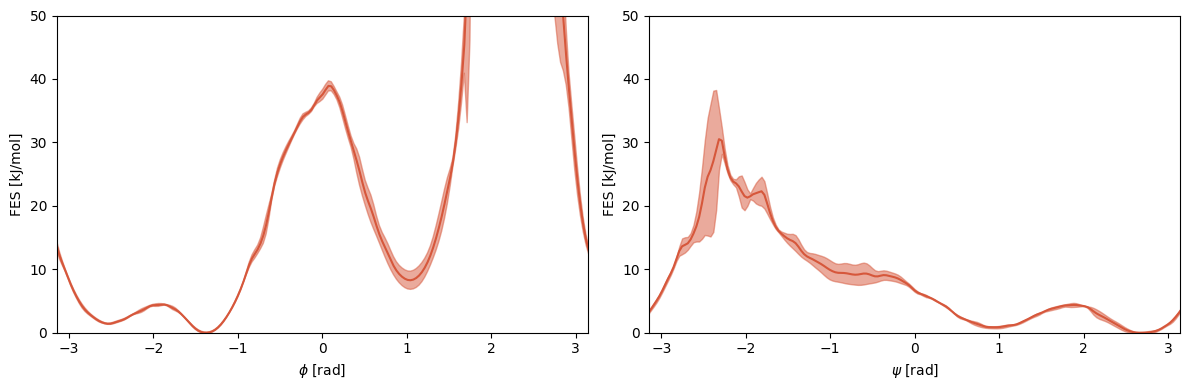

In [98]:
# compute weights
kbT = 2.5

#w = np.exp(colvar['metad.bias'].values/kbT)

#phi = colvar['phi'].values

fig,axs = plt.subplots(1,2,figsize=(12,4),dpi=100)
ax = axs[0]
fes,grid,bounds,error = compute_fes(phi_ml, weights=w_phi_ml, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\phi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

ax = axs[1]
fes,grid,bounds,error = compute_fes(psi_ml, weights=w_psi_ml, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\psi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

plt.tight_layout()

Once we have obtained a reasonable sampling, we can try to understand what the NN has learnt. A naive guess would be to compute the correlation between the DeepLDA CV and all the input distances. 

--> **Question**: Can we identify some features that are more correlated than others? You can also try to use `method='spearman'` in the correlation function, which rather than looking for a linear correlation only assesses how well the relationship between two variables can be described using a monotonic function.

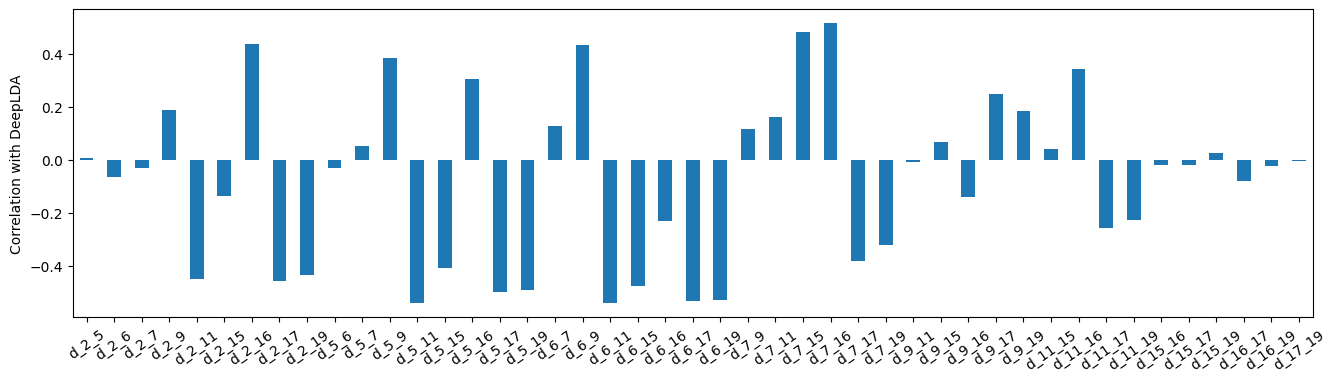

In [99]:
cols = ['deep.node-0']
cols.extend(colvar_ml.filter(regex='d_').columns)
corr = colvar_ml[cols].corr(method='pearson') 

fig,ax = plt.subplots(figsize=(16,4),dpi=100)

corr['deep.node-0'].drop('deep.node-0').plot(kind='bar', ax=ax, rot=35)
ax.set_ylabel('Correlation with DeepLDA')
plt.show()

Since the relationship between the input distances and the DeepLDA CV is not linear, understanding what the NN has learnt might not be an easy job. Hovewer, we could try to see whether we detect any correlation with respect to other physical descriptors which might play a role in the transition between the two states. 

--> **Exercise**: compute the correlation between the DeepLDA CV and the torsion angles computed in the PLUMED input file.

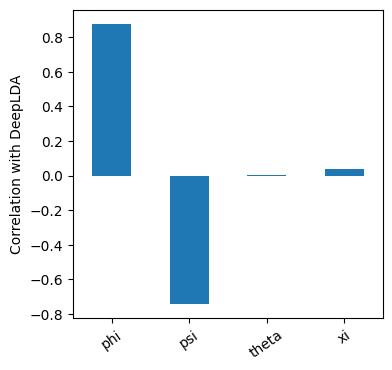

In [100]:
# select deelda and input distances, as well as dihedral angles
#cols = ['deep.node-0', ______FILL______ ]
cols = ['deep.node-0', 'phi', 'psi', 'theta', 'xi']

# compute correlation
corr = colvar_ml[cols].corr(method='spearman')

# plot
fig,ax = plt.subplots(figsize=(4,4),dpi=100)
corr['deep.node-0'].drop('deep.node-0').plot(kind='bar', ax=ax, rot=35)
ax.set_ylabel('Correlation with DeepLDA')
plt.show()

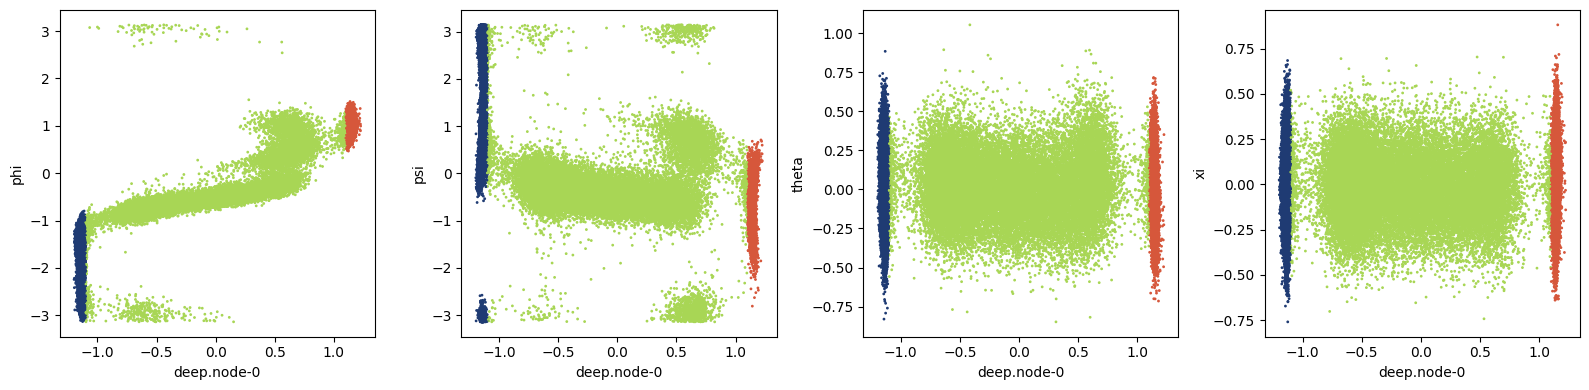

In [101]:
fig,axs = plt.subplots(1,len(cols)-1,figsize=(16,4),dpi=100)

state = np.zeros(len(colvar_ml))

state[colvar_ml['deep.node-0']<-1.1] = -1
state[colvar_ml['deep.node-0']>1.1] = 1

colvar_ml['state'] = state

for i,desc in enumerate(cols[1:]):
    colvar_ml.plot.scatter('deep.node-0',desc,c='state',s=1,ax=axs[i],cmap='fessa',colorbar=False)

plt.tight_layout()

### hills plot

Text(0, 0.5, 'height [kj/mol]')

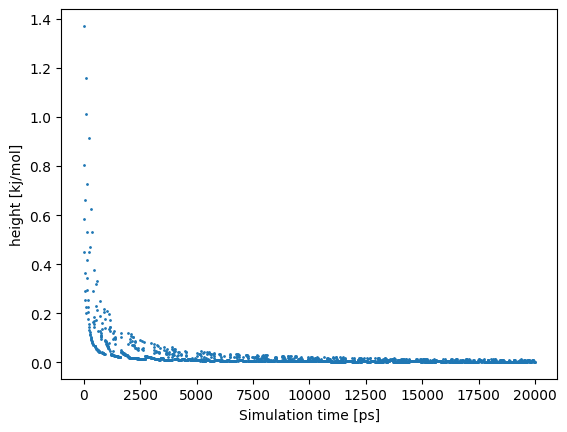

In [102]:
# visualize CV file
#data=plumed.read_as_pandas(str(folder_phi /"HILLS"))
data=load_dataframe(f"{folder_ml}/HILLS")
# plot hills height
plt.plot(data["time"][::10],data["height"][::10],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time [ps]")
plt.ylabel("height [kj/mol]")

In [103]:
# compute free energy as a function of simulation time

#plumed sum_hills --hills HILLS --stride 200 --mintozero
execute("plumed sum_hills --hills HILLS --stride 200 --mintozero", folder=folder_ml)

Completed: plumed sum_hills --hills HILLS --stride 200 --mintozero


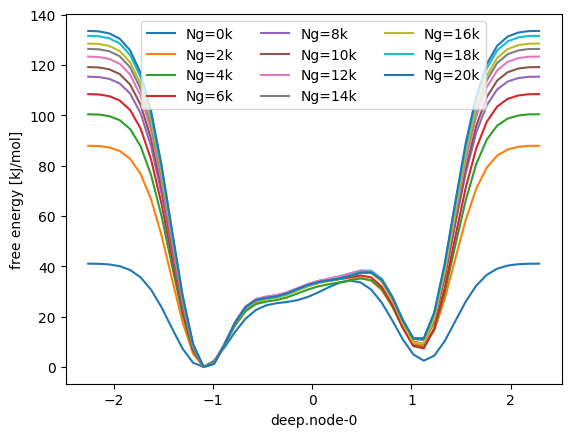

In [104]:
# plot free energy as a function of simulation time
#for i in range(0,51,10):
for i in range(0,101,10):    
 # import fes file into pandas dataset
#  data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 data = load_dataframe(f"{folder_ml}/fes_{i}.dat")

 # plot fes
 plt.plot(data["deep.node-0"],data["file.free"], label="Ng="+str(int(2*i/10))+"k") 
# labels
plt.xlabel("deep.node-0")
plt.ylabel("free energy [kJ/mol]")
plt.legend(ncol=3)

Text(0, 0.5, 'DeltaF [kJ/mol]')

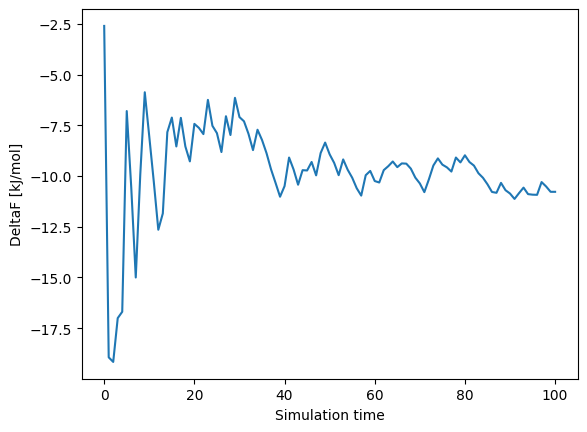

In [106]:
# calculate free-energy difference
DeltaF=[]; kbt=2.494339
# cycle on free-energy profiles
#for i in range(0,51):
for i in range(0,101):   
 # import fes file into pandas dataset
#  data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 data = load_dataframe(f"{folder_ml}/fes_{i}.dat")
 # find minimum value of fes
 minf = min(data["file.free"])
 # plot fes
 F0=0.0; F1=0.0
 for j in range(0, len(data["deep.node-0"])):
     dn = data["deep.node-0"][j]
     # calculate probability
     p = math.exp((-data["file.free"][j]+minf)/kbt)
     # integrate in the two basins
     if(-1.5<=dn<=-0.5):   F0 += p
     if(0.5<=dn<=1.5): F1 += p
 # calculate free energy difference and add to list
 DeltaF.append(-kbt*math.log(F0/F1))         
# plot
plt.plot(DeltaF) 
# labels
plt.xlabel("Simulation time")
plt.ylabel("DeltaF [kJ/mol]")

### reweighting deepLDA

In [72]:
# CREATE FOLDER AND COPY INPUTS
folder_ml_rw = DATA_DIR / "2_meta-deeplda-rw/"
Path(folder_ml_rw).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_ml_rw)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_ml_rw)
execute(f"cp {folder_ml}/model.ptc .", folder_ml_rw)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data2/1_meta-deeplda/model.ptc .


In [73]:
# WRITE PLUMED INPUT FILE
with open(folder_ml_rw / "plumed_reweight.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

metad: METAD ARG=deep.node-0 ...
   # Deposit a Gaussian every 10000000 time steps (never!), with initial height equal to 0.0 kJ/mol 
   PACE=10000000 HEIGHT=0.0 BIASFACTOR=8# <- this is the new stuff! 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE={folder_ml}/HILLS GRID_MIN=-pi GRID_MAX=pi
   # Say that METAD should be restarting (= reading an existing HILLS file) 
   RESTART=YES # <- this is the new stuff! 
...

# Use the metadynamics bias as argument
as: REWEIGHT_BIAS ARG=metad.bias 
# Calculate histograms of phi and psi dihedrals every 50 steps
# using the weights obtained from the metadynamics bias potentials (umbrella-sampling-like reweighting)
# Look at the manual to understand the parameters of the HISTOGRAM action!
hhphi: HISTOGRAM ARG=phi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
hhpsi: HISTOGRAM ARG=psi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
# Convert histograms h(s) to free energies F(s) = -kBT * log(h(s))
ffphi: CONVERT_TO_FES GRID=hhphi 
ffpsi: CONVERT_TO_FES GRID=hhpsi 
# Print out the free energies F(s) to file once the entire trajectory is processed
DUMPGRID GRID=ffphi FILE=ffphi.dat 
DUMPGRID GRID=ffpsi FILE=ffpsi.dat 

# Print out the values of phi, psi and the metadynamics bias potential
# Make sure you print out the 3 variables in the specified order at every step
PRINT ARG=phi,psi,deep.node-0,metad.bias FILE=COLVAR_REWEIGHT STRIDE=1 # <- also change this one!
ENDPLUMED
""")

In [107]:
# analyze with PLUMED driver
execute(f"plumed driver --mf_xtc {folder_ml}/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339", folder=folder_ml_rw)

Completed: plumed driver --mf_xtc /home/dani/wslcoding/MCFM/ML-CV/data2/1_meta-deeplda/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339


In [108]:
# colvar =plumed.read_as_pandas(str(folder_rw /"COLVAR_REWEIGHT"))
colvar_ml_rw =load_dataframe(f"{folder_ml_rw}/COLVAR_REWEIGHT")

(0.0, 50.0)

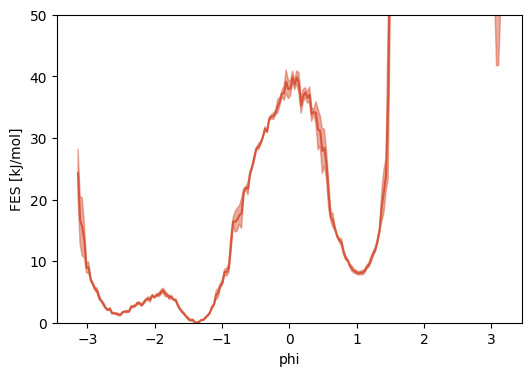

In [109]:
s = colvar_ml_rw['phi'].values

# compute weights
kbT = 2.5
w = np.exp(colvar_ml_rw['metad.bias'].values/kbT)

fig,ax = plt.subplots(figsize=(6,4),dpi=100)
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('phi')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)

(0.0, 50.0)

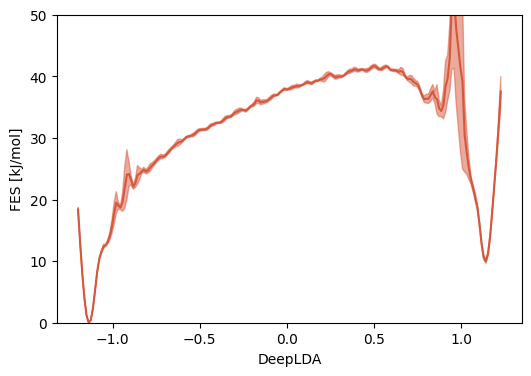

In [110]:
s = colvar_ml_rw['deep.node-0'].values

# compute weights
kbT = 2.5
w = np.exp(colvar_ml_rw['metad.bias'].values/kbT)

fig,ax = plt.subplots(figsize=(6,4),dpi=100)
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('DeepLDA')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)

In [111]:

dn = colvar_ml_rw['deep.node-0'].values

w = np.exp(colvar_ml_rw['metad.bias'].values/kbT)

bandwidth = 0.05

dn, w_dn = augment_periodic(dn,w,bandwidth)


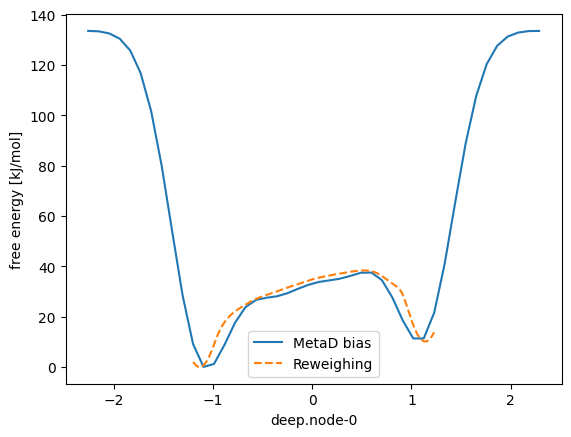

In [113]:
# now compare free energy from metadynamics bias and reweighting
#data_b=load_dataframe(f"{folder_ml}/fes_100.dat")
data_b=load_dataframe(f"{folder_ml}/fes_100.dat")
data_r=load_dataframe(f"{folder_ml_rw}/ffphi.dat")  

fes,grid,bounds,error = compute_fes(dn, weights=w_dn, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)

# plot free energies
plt.plot(data_b["deep.node-0"],data_b["file.free"],label="MetaD bias")
plt.plot(grid,fes-min(fes),label="Reweighing", linestyle='--')
# x-y axis labels
plt.xlabel("deep.node-0")
plt.ylabel("free energy [kJ/mol]")
plt.legend()

### block analysis deepLDA

In [83]:
# CREATE FOLDER AND COPY INPUTS
folder_ml_bl = DATA_DIR / "3_meta-deeplda-block/"
Path(folder_ml_bl).mkdir(parents=True, exist_ok=True)

In [17]:
script_block_fes = str(BASE_DIR  / "notebook/do_block_fes.py")

In [ ]:
os.environ["DIR_3"] = str(folder_ml_rw)
os.environ["SCRIPT_FES"] = str(script_block_fes)

bash_script = """
# create phi.weight file with phi and weight from COLVAR_REWEIGHT
# find maximum of bias
bmax=`sort -n -k 5 "$DIR_3/COLVAR_REWEIGHT" | tail -n 1 | awk '{print $5}'`
# create phi.weight file
awk '{if($1!="#!") print $2,exp(($5-bm)/2.494339)}' bm=$bmax "$DIR_3/COLVAR_REWEIGHT" > phi.weight

# and now do block analysis with block sizes from 1 to 1000 (every 10)
# create PLUMED-like header for output file
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 # run the python script
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 # calculate average error along the free-energy profile
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks
"""

In [114]:
execute(bash_script, folder=folder_ml_bl)

Completed: 
# create phi.weight file with phi and weight from COLVAR_REWEIGHT
# find maximum of bias
bmax=`sort -n -k 4 "$DIR_3/COLVAR_REWEIGHT" | tail -n 1 | awk '{print $4}'`
# create phi.weight file
awk '{if($1!="#!") print $2,exp(($4-bm)/2.494339)}' bm=$bmax "$DIR_3/COLVAR_REWEIGHT" > phi.weight

# and now do block analysis with block sizes from 1 to 1000 (every 10)
# create PLUMED-like header for output file
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 # run the python script
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 # calculate average error along the free-energy profile
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks



Text(0, 0.5, 'Average error on free-energy profile [kJ/mol]')

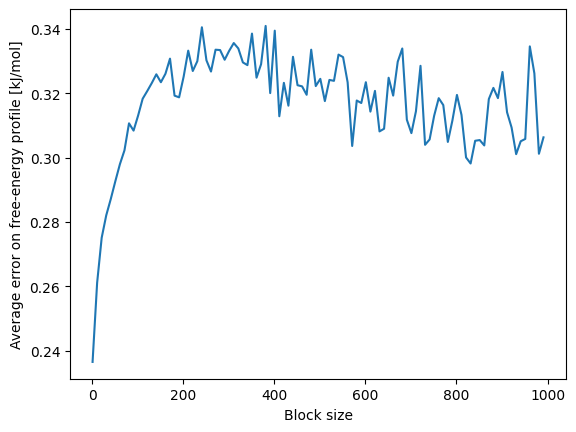

In [115]:
# import err.blocks file into pandas dataset
# data=plumed.read_as_pandas(str(f"{folder_bl}/err.blocks"))
data=load_dataframe(f"{folder_ml_bl}/err.blocks")
# plot error as a function of block size
plt.plot(data["bsize"],data["err"])
# x-y axis labels
plt.xlabel("Block size")
plt.ylabel("Average error on free-energy profile [kJ/mol]")

### Bonus exercise: stretching the CV

In [8]:
folder_ml_s = DATA_DIR / "4_meta-deeplda-stretch/"
Path(folder_ml_s).mkdir(parents=True, exist_ok=True)
execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_ml_s)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_ml_s)

# export model
execute(f"cp {folder_ml}/model.ptc .", folder=folder_ml_s)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data2/1_meta-deeplda/model.ptc .


In [9]:
# WRITE PLUMED INPUT FILE
with open(folder_ml_s / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

# Stretch the CV
deep_mod: CUSTOM ARG=deep.node-0 FUNC=x+x^3 PERIODIC=NO

metad: METAD ARG=deep_mod ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-50 GRID_MAX=50 
...

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [11]:
num_steps = 10_000_000

In [12]:
# print command to run in terminal (for longer run)

print(f"cd {folder_ml_s}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data2/4_meta-deeplda-stretch
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000000 -v


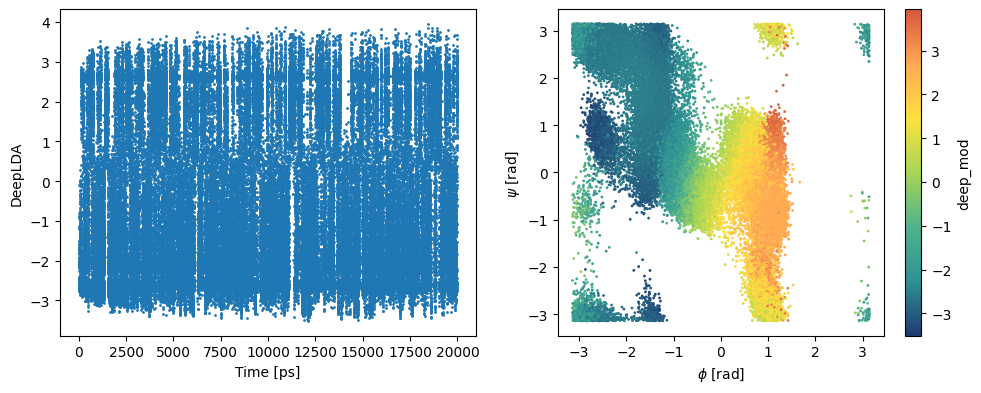

In [13]:
colvarS = load_dataframe(f"{folder_ml_s}/COLVAR")

fig,axs = plt.subplots(1,2,figsize=(10,4),dpi=100)
# Time evolution (DeepLDA)
colvarS.plot.scatter('time','deep_mod',s=1,ax=axs[0])
axs[0].set_xlabel('Time [ps]')
axs[0].set_ylabel('DeepLDA')
# 2D scatter plot colored with DeepLDA
colvarS.plot.scatter('phi','psi',c='deep_mod',s=1,cmap='fessa',ax=axs[1])
axs[1].set_xlabel(r'$\phi$ [rad]')
axs[1].set_ylabel(r'$\psi$ [rad]')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

(0.0, 50.0)

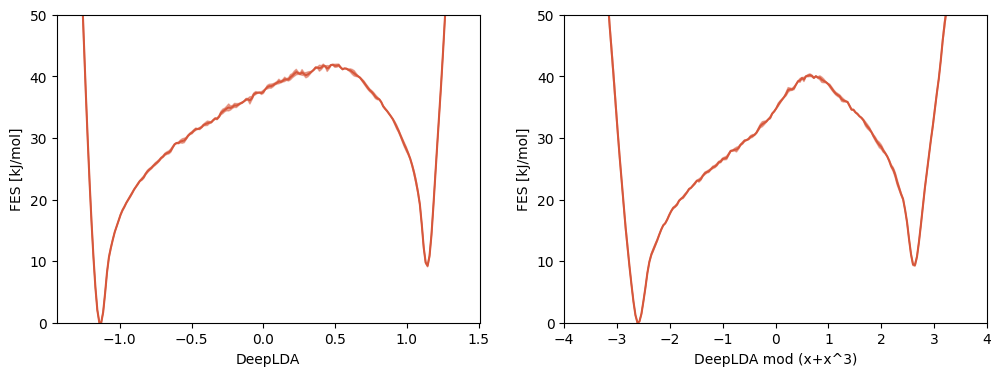

In [14]:
s = colvarS['deep.node-0'].values
s2 = colvarS['deep_mod'].values

# compute weights
kbT = 2.5
w = np.exp(colvarS['metad.bias'].values/kbT)

fig,axs = plt.subplots(1,2,figsize=(12,4),dpi=100)
ax = axs[0]
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('DeepLDA')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)

ax = axs[1]
fes,grid,bounds,error = compute_fes(s2, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.02, 
                                    plot=True, ax = ax)
ax.set_xlabel('DeepLDA mod (x+x^3)')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-4,4)
ax.set_ylim(0,50)

In [27]:
# CREATE FOLDER AND COPY INPUTS
folder_ml_s_rw = DATA_DIR / "5_meta-deeplda-stretch-rw/"
Path(folder_ml_s_rw).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_ml_s_rw)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_ml_s_rw)
execute(f"cp {folder_ml_s}/model.ptc .", folder_ml_s_rw)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data2/4_meta-deeplda-stretch/model.ptc .


In [38]:
# WRITE PLUMED INPUT FILE
with open(folder_ml_s_rw / "plumed_reweight.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

# Stretch the CV
deep_mod: CUSTOM ARG=deep.node-0 FUNC=x+x^3 PERIODIC=NO

metad: METAD ARG=deep_mod ...
   # Deposit a Gaussian every 10000000 time steps (never!), with initial height equal to 0.0 kJ/mol 
   PACE=10000000 HEIGHT=0.0 BIASFACTOR=8# <- this is the new stuff! 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE={folder_ml_s}/HILLS GRID_MIN=-50 GRID_MAX=50
   # Say that METAD should be restarting (= reading an existing HILLS file) 
   RESTART=YES # <- this is the new stuff! 
...

# Use the metadynamics bias as argument
as: REWEIGHT_BIAS ARG=metad.bias 
# Calculate histograms of phi and psi dihedrals every 50 steps
# using the weights obtained from the metadynamics bias potentials (umbrella-sampling-like reweighting)
# Look at the manual to understand the parameters of the HISTOGRAM action!
hhphi: HISTOGRAM ARG=phi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
hhpsi: HISTOGRAM ARG=psi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
# Convert histograms h(s) to free energies F(s) = -kBT * log(h(s))
ffphi: CONVERT_TO_FES GRID=hhphi 
ffpsi: CONVERT_TO_FES GRID=hhpsi 
# Print out the free energies F(s) to file once the entire trajectory is processed
DUMPGRID GRID=ffphi FILE=ffphi.dat 
DUMPGRID GRID=ffpsi FILE=ffpsi.dat 

# Print out the values of phi, psi and the metadynamics bias potential
# Make sure you print out the 3 variables in the specified order at every step
PRINT ARG=phi,psi,deep.node-0,deep_mod,metad.bias FILE=COLVAR_REWEIGHT STRIDE=1 # <- also change this one!
ENDPLUMED
""")

In [39]:
# analyze with PLUMED driver
execute(f"plumed driver --mf_xtc {folder_ml_s}/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339", folder=folder_ml_s_rw)

Completed: plumed driver --mf_xtc /home/dani/wslcoding/MCFM/ML-CV/data2/4_meta-deeplda-stretch/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339


In [ ]:
# CREATE FOLDER AND COPY INPUTS
folder_ml_s_bl = DATA_DIR / "6_meta-deeplda-stretch-block/"
Path(folder_ml_s_bl).mkdir(parents=True, exist_ok=True)

In [46]:
os.environ["DIR_3"] = str(folder_ml_s_rw)
os.environ["SCRIPT_FES"] = str(script_block_fes)

bash_script = """
# create phi.weight file with phi and weight from COLVAR_REWEIGHT
# find maximum of bias
bmax=`sort -n -k 6 "$DIR_3/COLVAR_REWEIGHT" | tail -n 1 | awk '{print $6}'`
# create phi.weight file
awk '{if($1!="#!") print $2,exp(($6-bm)/2.494339)}' bm=$bmax "$DIR_3/COLVAR_REWEIGHT" > phi.weight

# and now do block analysis with block sizes from 1 to 1000 (every 10)
# create PLUMED-like header for output file
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 # run the python script
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 # calculate average error along the free-energy profile
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks
"""

In [47]:
execute(bash_script, folder=folder_ml_s_bl)

Completed: 
# create phi.weight file with phi and weight from COLVAR_REWEIGHT
# find maximum of bias
bmax=`sort -n -k 6 "$DIR_3/COLVAR_REWEIGHT" | tail -n 1 | awk '{print $6}'`
# create phi.weight file
awk '{if($1!="#!") print $2,exp(($6-bm)/2.494339)}' bm=$bmax "$DIR_3/COLVAR_REWEIGHT" > phi.weight

# and now do block analysis with block sizes from 1 to 1000 (every 10)
# create PLUMED-like header for output file
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 # run the python script
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 # calculate average error along the free-energy profile
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks



Text(0, 0.5, 'Average error on free-energy profile [kJ/mol]')

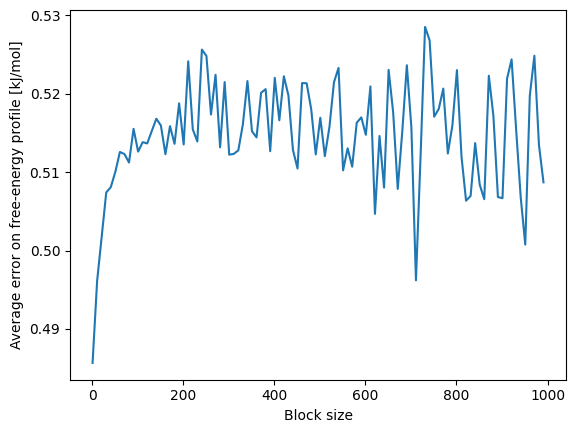

In [48]:
# import err.blocks file into pandas dataset
# data=plumed.read_as_pandas(str(f"{folder_bl}/err.blocks"))
data=load_dataframe(f"{folder_ml_s_bl}/err.blocks")
# plot error as a function of block size
plt.plot(data["bsize"],data["err"])
# x-y axis labels
plt.xlabel("Block size")
plt.ylabel("Average error on free-energy profile [kJ/mol]")

### bonus